In [1]:
#conversacion con gemini

import os
import subprocess
try:
    _printenv = subprocess.run(
        ['bash', '-c', 'source ~/.bashrc 2>/dev/null && printenv'],
        text=True, capture_output=True, timeout=10,
    ).stdout
    for _line in _printenv.splitlines():
        if '=' in _line:
            _k, _v = _line.split('=', 1)
            os.environ.setdefault(_k, _v)
except Exception:
    pass
if 'PDK_ROOT' in os.environ and 'PDK' in os.environ:
    os.environ.setdefault('PDKPATH', os.path.join(os.environ['PDK_ROOT'], os.environ['PDK']))

In [2]:
import gdstk
import svgutils.transform as sg
import IPython.display
from IPython.display import clear_output
import ipywidgets as widgets

# Redirect all outputs here
hide = widgets.Output()

def display_gds(gds_file,path,scale = 3):
  
  # Generate an SVG image
  top_level_cell = gdstk.read_gds(gds_file).top_level()[0]
  top_level_cell.write_svg(os.path.join(path,'out.svg'))
    
  # Scale the image for displaying
  fig = sg.fromfile(os.path.join(path,'out.svg'))
  fig.set_size((str(float(fig.width) * scale), str(float(fig.height) * scale)))
  fig.save(os.path.join(path,'out.svg'))

  # Display the image
  IPython.display.display(IPython.display.SVG(os.path.join(path,'out.svg')))
  os.remove(os.path.join(path,'out.gds'))

def display_component(component,path,scale = 3):
  # Save to a GDS file
  with hide:
    component.write_gds(os.path.join(path,'out.gds'))
  display_gds(os.path.join(path,'out.gds'),path,scale)

In [3]:
# %%
import os
import gdsfactory as gf
from gdsfactory import Component
from glayout import MappedPDK, gf180
from glayout import nmos, pmos
from glayout.primitives.mimcap import mimcap, mimcap_array
from glayout.routing.straight_route import straight_route
from glayout.routing.c_route import c_route
from glayout.routing.L_route import L_route
from glayout.util.comp_utils import align_comp_to_port, evaluate_bbox

In [4]:


integrator_config = {
    "pdk": gf180,
    "layout_rules": {
        "spacing": gf180.util_max_metal_seperation(),
        "routing_metal": "met2",
        "dummy_devices": True,
        "tie_layers": ("met2", "met1"),
        "sd_rmult": 1,
    },
}

# Base parameters for PMOS and NMOS
nmos_kwargs = {
    "with_tie": False,
    "with_dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2", "met1"),
    "dummy_routes": True,
}

pmos_kwargs = {
    "with_tie": False,
    "dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2", "met1"),
    "dummy_routes": True,
}

In [ ]:
# .subckt integrator_final_mike Vext_pin avdd avss I_50n
# *.PININFO Vext_pin:I avdd:B avss:B I_50n:I
# XM1 vg vg vm avdd pfet_03v3 L=.28u W=1u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
# + ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0
# XM6 vm Vext_pin avdd avss nfet_03v3 L=0.28u W=1u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
# + ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0
# XM2 avss I_50n vg avss nfet_03v3 L=0.28u W=1u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
# + ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0
# XM3 I_50n I_50n avss avss nfet_03v3 L=0.28u W=1u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
# + ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0
# XC3 vm avss cap_mim_2f0fF c_width=17.68e-6 c_length=17.68e-6 m=8
# .ends


In [11]:
# ----------------------------------------------------------------------
# 2. Instantiate Devices
# ----------------------------------------------------------------------
pdk = integrator_config["pdk"]
integrator = Component(name="integrator")

# PMOS Transistors (XM1, XM6)
xm1 = pmos(pdk, width=1.0, length=0.28, fingers=1, **pmos_kwargs)
xm6 = pmos(pdk, width=1.0, length=0.28, fingers=1, **pmos_kwargs)

# NMOS Transistors (XM2, XM3)
xm2 = nmos(pdk, width=1.0, length=0.28, fingers=1, **nmos_kwargs)
xm3 = nmos(pdk, width=1.0, length=0.28, fingers=1, **nmos_kwargs)

# MIM Capacitor Array XC3 (m=8, 2 rows x 4 columns)
xc3 = mimcap_array(
    pdk, 
    size=(17.68, 17.68), 
    rows=2, 
    columns=4
)

# Add components as references to the main cell
xm1_ref = integrator << xm1
xm6_ref = integrator << xm6
xm2_ref = integrator << xm2
xm3_ref = integrator << xm3
xc3_ref = integrator << xc3

# ----------------------------------------------------------------------
# 3. Component Placement & Floorplanning
# ----------------------------------------------------------------------
# Row 1 (Top): PMOS transistors side-by-side
xm1_ref.move((0, 30))
xm6_ref.move((15, 30))

# Row 2 (Middle): Big MIM Capacitor Array
xc3_ref.move((0, 0))

# Row 3 (Bottom): NMOS transistors side-by-side
xm2_ref.move((0, -25))
xm3_ref.move((15, -25))

# ----------------------------------------------------------------------
# 4. Routing Net Connections
# ----------------------------------------------------------------------

# --- Net: vg (Diode connection XM1 Drain <-> Gate, and to XM2 Gate) ---
# Diode connection on XM1: Drain_E to Gate_E
route_vg_diode = c_route(
    pdk, 
    xm1_ref.ports["multiplier_0_drain_E"], 
    xm1_ref.ports["multiplier_0_gate_E"]
)
integrator.add(route_vg_diode)

# XM1 Gate to XM2 Gate
route_vg = straight_route(
    pdk, 
    xm1_ref.ports["multiplier_0_gate_W"], 
    xm2_ref.ports["multiplier_0_gate_W"]
)
integrator.add(route_vg)

# --- Net: I_50n (Diode connection XM3 Drain <-> Gate, and to XM2 Source) ---
# Diode connection on XM3
route_i50n_diode = c_route(
    pdk, 
    xm3_ref.ports["multiplier_0_drain_E"], 
    xm3_ref.ports["multiplier_0_gate_E"]
)
integrator.add(route_i50n_diode)

# XM3 Gate to XM2 Source
route_i50n = straight_route(
    pdk, 
    xm3_ref.ports["multiplier_0_gate_W"], 
    xm2_ref.ports["multiplier_0_source_E"]
)
integrator.add(route_i50n)

# --- Net: vm (XM1 Source to XM6 Drain to MIM Cap Top Plate) ---
route_vm_p = straight_route(
    pdk, 
    xm1_ref.ports["multiplier_0_source_E"], 
    xm6_ref.ports["multiplier_0_drain_W"]
)
integrator.add(route_vm_p)

route_vm_cap = L_route(
    pdk, 
    xm1_ref.ports["multiplier_0_source_W"], 
    xc3_ref.ports["row0_col1_array_row2_col0_top_met_N"]
)
integrator.add(route_vm_cap)

# --- Net: avss (XM2 Drain, XM3 Source, and MIM Cap Bottom Plate) ---
route_avss_nmos = straight_route(
    pdk, 
    xm2_ref.ports["multiplier_0_drain_E"], 
    xm3_ref.ports["multiplier_0_source_W"]
)
integrator.add(route_avss_nmos)

route_avss_cap = L_route(
    pdk, 
    xm3_ref.ports["multiplier_0_source_E"], 
    xc3_ref.ports["row0_col1_array_row2_col0_bottom_met_S"]
)
integrator.add(route_avss_cap)

# ----------------------------------------------------------------------
# 5. Add Global Pins / Ports and Export GDS
# ----------------------------------------------------------------------
integrator.add_port("Vext_pin", port=xm6_ref.ports["multiplier_0_gate_E"])
integrator.add_port("I_50n", port=xm3_ref.ports["multiplier_0_gate_E"])
integrator.add_port("avdd", port=xm6_ref.ports["multiplier_0_source_E"])
integrator.add_port("avss", port=xc3_ref.ports["row0_col1_array_row2_col0_bottom_met_S"])

{'name': 'avss', 'width': 0.5, 'center': [12.48, -6.25], 'orientation': 270.0, 'layer': [36, 0], 'port_type': 'electrical'}

In [12]:
integrator.show()

/headless/conda-env/miniconda3/envs/GLdev/lib/python3.10/site-packages/gdsfactory/show.py:40: UserWarning: Unnamed cells, 5 in 'integrator$3'
  gdspath = component.write_gds(
2026-08-01 21:06:55.461 | INFO     | gdsfactory.klive:show:55 - Message from klive: {"version": "0.4.1", "klayout_version": "0.30.8", "type": "open", "file": "/tmp/gdsfactory/integrator$3.gds"}


In [9]:
xc3_ref.ports

{'row0_col0_array_row0_col0_bottom_layer_W': {'name': 'row0_col0_array_row0_col0_bottom_layer_W', 'width': 0.5, 'center': [-7.85, -7.6], 'orientation': 180.0, 'layer': [36, 0], 'port_type': 'electrical'},
 'row0_col0_array_row0_col0_bottom_via_W': {'name': 'row0_col0_array_row0_col0_bottom_via_W', 'width': 0.26, 'center': [-7.73, -7.6], 'orientation': 180.0, 'layer': [38, 0], 'port_type': 'electrical'},
 'row0_col0_array_row0_col0_bottom_met_W': {'name': 'row0_col0_array_row0_col0_bottom_met_W', 'width': 0.5, 'center': [-7.85, -7.6], 'orientation': 180.0, 'layer': [36, 0], 'port_type': 'electrical'},
 'row0_col0_array_row0_col0_top_met_W': {'name': 'row0_col0_array_row0_col0_top_met_W', 'width': 0.5, 'center': [-7.85, -7.6], 'orientation': 180.0, 'layer': [42, 0], 'port_type': 'electrical'},
 'row0_col0_array_row0_col1_bottom_layer_W': {'name': 'row0_col0_array_row0_col1_bottom_layer_W', 'width': 0.5, 'center': [-7.05, -7.6], 'orientation': 180.0, 'layer': [36, 0], 'port_type': 'electr

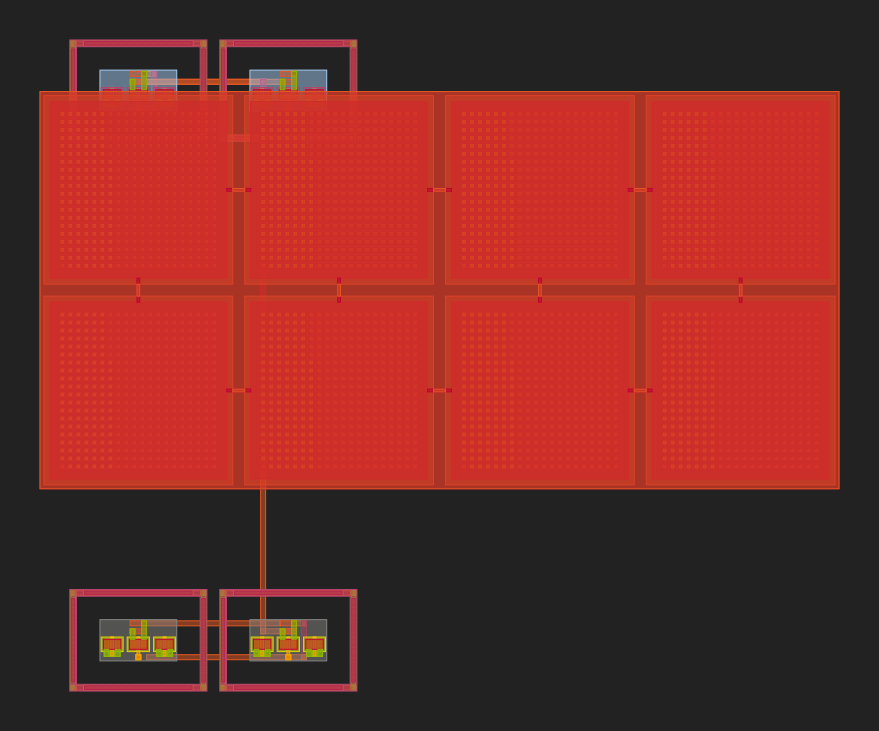

In [13]:
display_component(integrator, scale = 1,path=".")